# 🌿 BIODATUM — Protótipo de Ecologia Florestal
### Plataforma Prescritiva de Inteligência Climática e Bioeconômica da Amazônia

**Universidade Federal do Amazonas — PPGCASA**  
**Linha de Pesquisa:** Dinâmicas Socioambientais  

---

Este protótipo demonstra dois módulos centrais da plataforma BIODATUM:

1. **Estimativa de Biomassa** — via equação alométrica do Protocolo Higuchi
2. **IRFA** — Índice de Resiliência Florestal Amazônica

> *Este notebook foi desenvolvido como demonstração científica para avaliação acadêmica.*

## 0. Configuração do Ambiente

In [1]:
# Importações necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Paleta de cores BIODATUM
COR_VERDE_ESCURO = '#1B5E20'
COR_VERDE_MEDIO = '#388E3C'
COR_VERDE_CLARO = '#81C784'
COR_LARANJA     = '#F57C00'
COR_VERMELHO    = '#C62828'

print('✅ Ambiente configurado com sucesso.')

✅ Ambiente configurado com sucesso.


---
## 1. Introdução

A Floresta Amazônica abriga cerca de **10% de toda a biodiversidade do planeta** e desempenha papel regulador fundamental no clima global. Estimar com precisão a biomassa florestal e monitorar a resiliência dos ecossistemas são etapas essenciais para a gestão territorial e para a valoração da sociobiodiversidade amazônica.

### Protocolo Higuchi
O **Protocolo Higuchi** (Higuchi et al., 1998) estabelece equações alométricas calibradas especificamente para espécies da Amazônia central. A equação utilizada neste módulo é:

$$AGB = e^{-1{,}499 + 2{,}148 \cdot \ln(DAP) + 0{,}207 \cdot [\ln(DAP)]^2 - 0{,}0281 \cdot [\ln(DAP)]^3}$$

Onde **DAP** é o Diâmetro à Altura do Peito (cm) e **AGB** é a biomassa aérea (Mg/ha).

### Índice IRFA
O **Índice de Resiliência Florestal Amazônica (IRFA)** integra três dimensões ecológicas:

$$IRFA = \alpha \cdot TNR + \beta \cdot TRB + \gamma \cdot IEC$$

| Componente | Descrição |
|---|---|
| **TNR** | Taxa de Regeneração Natural |
| **TRB** | Taxa de Recuperação de Biomassa |
| **IEC** | Índice de Estrutura Comunitária |
| **α, β, γ** | Pesos (0,33 cada — distribuição equânime) |

---
## 2. Estimativa de Biomassa — Protocolo Higuchi

In [2]:
def estimar_biomassa(dap):
    """
    Estima a biomassa aérea (AGB) utilizando a equação alométrica do Protocolo Higuchi.

    Referência: Higuchi et al. (1998) — equação calibrada para a Amazônia central.

    Parâmetros
    ----------
    dap : float ou list/array
        Diâmetro à Altura do Peito em centímetros (DAP ≥ 10 cm).

    Retorna
    -------
    numpy.ndarray
        Biomassa aérea em Mg/ha.
    """
    dap = np.atleast_1d(np.array(dap, dtype=float))

    # Validação: DAP mínimo = 10 cm (limiar padrão para inventários florestais)
    if np.any(dap < 10):
        raise ValueError("DAP deve ser ≥ 10 cm. Valores abaixo do limiar não são válidos para esta equação.")

    ln_dap = np.log(dap)  # logaritmo natural

    # Equação alométrica Higuchi et al. (1998)
    agb = np.exp(
        -1.499
        + 2.148 * ln_dap
        + 0.207 * ln_dap**2
        - 0.0281 * ln_dap**3
    )

    return agb


# -------------------------------------------------------
# Dataset simulado — parcela florestal amazônica típica
# Representa uma amostra de 15 árvores em uma parcela de 1 ha
# -------------------------------------------------------
np.random.seed(42)  # reprodutibilidade

dados_arvores = {
    'ID': [f'ARV-{str(i).zfill(2)}' for i in range(1, 16)],
    'Espécie': [
        'Bertholletia excelsa',   # Castanheira
        'Cedrelinga cateniformis',# Cedrorana
        'Manilkara huberi',       # Maçaranduba
        'Swietenia macrophylla',  # Mogno
        'Ceiba pentandra',        # Sumaúma
        'Hymenaea courbaril',     # Jatobá
        'Dinizia excelsa',        # Angelim-vermelho
        'Peltogyne paniculata',   # Roxinho
        'Couratari guianensis',   # Tauari
        'Virola surinamensis',    # Virola
        'Ocotea cymbarum',        # Louro-inhamui
        'Licaria brasiliensis',   # Louro-preto
        'Astronium lecointei',    # Muiracatiara
        'Mezilaurus itauba',      # Itaúba
        'Brosimum rubescens'      # Pau-rainha
    ],
    'DAP_cm': [85, 120, 45, 60, 150, 55, 180, 30, 70, 25, 35, 40, 95, 110, 28]
}

df = pd.DataFrame(dados_arvores)

# Aplicar a função de estimativa
df['AGB_Mg_ha'] = estimar_biomassa(df['DAP_cm'].values)

# Classificar por porte
def classificar_porte(dap):
    if dap < 40:   return 'Pequeno (< 40 cm)'
    elif dap < 80: return 'Médio (40–80 cm)'
    else:          return 'Grande (> 80 cm)'

df['Porte'] = df['DAP_cm'].apply(classificar_porte)

# Exibir tabela formatada
print('=' * 70)
print('         ESTIMATIVA DE BIOMASSA — PROTOCOLO HIGUCHI')
print('=' * 70)
print(df[['ID', 'Espécie', 'DAP_cm', 'AGB_Mg_ha', 'Porte']]
      .to_string(index=False, float_format='{:.4f}'.format))
print('=' * 70)
print(f'\n📊 RESUMO DA PARCELA')
print(f'   Número de árvores  : {len(df)}')
print(f'   Biomassa total     : {df["AGB_Mg_ha"].sum():.2f} Mg/ha')
print(f'   Biomassa média     : {df["AGB_Mg_ha"].mean():.2f} Mg/ha')
print(f'   DAP médio          : {df["DAP_cm"].mean():.1f} cm')
print(f'   Maior árvore       : {df.loc[df["AGB_Mg_ha"].idxmax(), "Espécie"]} ({df["AGB_Mg_ha"].max():.2f} Mg/ha)')

         ESTIMATIVA DE BIOMASSA — PROTOCOLO HIGUCHI
    ID                 Espécie  DAP_cm  AGB_Mg_ha             Porte
ARV-01    Bertholletia excelsa      85 15763.4423  Grande (> 80 cm)
ARV-02 Cedrelinga cateniformis     120 34392.1708  Grande (> 80 cm)
ARV-03        Manilkara huberi      45  3385.4903  Médio (40–80 cm)
ARV-04   Swietenia macrophylla      60  6884.6686  Médio (40–80 cm)
ARV-05         Ceiba pentandra     150 55599.0555  Grande (> 80 cm)
ARV-06      Hymenaea courbaril      55  5566.9211  Médio (40–80 cm)
ARV-07         Dinizia excelsa     180 81027.7703  Grande (> 80 cm)
ARV-08    Peltogyne paniculata      30  1206.8489 Pequeno (< 40 cm)
ARV-09    Couratari guianensis      70  9978.9635  Médio (40–80 cm)
ARV-10     Virola surinamensis      25   751.9986 Pequeno (< 40 cm)
ARV-11         Ocotea cymbarum      35  1792.9515 Pequeno (< 40 cm)
ARV-12    Licaria brasiliensis      40  2517.3958  Médio (40–80 cm)
ARV-13     Astronium lecointei      95 20368.8314  Grande (> 80 

---
## 3. Índice de Resiliência Florestal Amazônica (IRFA)

In [3]:
def calcular_irfa(tnr, trb, iec, alpha=0.33, beta=0.33, gamma=0.33):
    """
    Calcula o Índice de Resiliência Florestal Amazônica (IRFA).

    O IRFA integra três dimensões ecológicas para mensurar a capacidade
    de recuperação de um ecossistema florestal após perturbação.

    Parâmetros
    ----------
    tnr : float ou array
        Taxa de Regeneração Natural (0 a 1).
    trb : float ou array
        Taxa de Recuperação de Biomassa (0 a 1).
    iec : float ou array
        Índice de Estrutura Comunitária (0 a 1).
    alpha, beta, gamma : float
        Pesos relativos de cada componente (padrão: 0.33 cada).

    Retorna
    -------
    numpy.ndarray
        Valores do IRFA (0 a 1).
    """
    tnr = np.atleast_1d(np.array(tnr, dtype=float))
    trb = np.atleast_1d(np.array(trb, dtype=float))
    iec = np.atleast_1d(np.array(iec, dtype=float))

    return alpha * tnr + beta * trb + gamma * iec


def classificar_irfa(valor):
    """
    Classifica o nível de resiliência com base no valor do IRFA.

    Critério:
        IRFA < 0.40  → Baixa resiliência
        0.40–0.70    → Média resiliência
        IRFA > 0.70  → Alta resiliência
    """
    if valor < 0.40:
        return 'Baixa'
    elif valor <= 0.70:
        return 'Média'
    else:
        return 'Alta'


# -------------------------------------------------------
# Dados simulados — três cenários ecológicos
# Representam diferentes estados de conservação
# -------------------------------------------------------

cenarios = {
    'Unidade de Conservação Integral\n(Baixo Impacto)': {
        'cor': COR_VERDE_ESCURO,
        # Alta regeneração, biomassa recuperada, estrutura preservada
        'tnr': np.random.uniform(0.75, 0.95, 8),
        'trb': np.random.uniform(0.72, 0.92, 8),
        'iec': np.random.uniform(0.78, 0.96, 8),
    },
    'Área de Uso Sustentável\n(Impacto Moderado)': {
        'cor': COR_LARANJA,
        # Regeneração e biomassa parcialmente comprometidas
        'tnr': np.random.uniform(0.40, 0.65, 8),
        'trb': np.random.uniform(0.38, 0.62, 8),
        'iec': np.random.uniform(0.42, 0.68, 8),
    },
    'Área Desmatada\n(Alto Impacto)': {
        'cor': COR_VERMELHO,
        # Degradação severa, baixa capacidade regenerativa
        'tnr': np.random.uniform(0.08, 0.30, 8),
        'trb': np.random.uniform(0.05, 0.28, 8),
        'iec': np.random.uniform(0.10, 0.32, 8),
    }
}

# Calcular IRFA para cada cenário e montar DataFrame
registros = []
for nome_cenario, dados in cenarios.items():
    irfa_vals = calcular_irfa(dados['tnr'], dados['trb'], dados['iec'])
    for i in range(len(irfa_vals)):
        registros.append({
            'Cenário': nome_cenario.replace('\n', ' '),
            'TNR': dados['tnr'][i],
            'TRB': dados['trb'][i],
            'IEC': dados['iec'][i],
            'IRFA': irfa_vals[i],
            'Resiliência': classificar_irfa(irfa_vals[i])
        })

df_irfa = pd.DataFrame(registros)

# Exibir resultados por cenário
print('=' * 72)
print('           ÍNDICE DE RESILIÊNCIA FLORESTAL AMAZÔNICA (IRFA)')
print('=' * 72)

for cenario in df_irfa['Cenário'].unique():
    sub = df_irfa[df_irfa['Cenário'] == cenario]
    print(f'\n📍 {cenario}')
    print(f'   IRFA médio   : {sub["IRFA"].mean():.4f}')
    print(f'   Resiliência  : {sub["Resiliência"].mode()[0]}')
    print(f'   TNR médio    : {sub["TNR"].mean():.3f} | TRB: {sub["TRB"].mean():.3f} | IEC: {sub["IEC"].mean():.3f}')

print()
print(df_irfa[['Cenário', 'TNR', 'TRB', 'IEC', 'IRFA', 'Resiliência']]
      .to_string(index=False, float_format='{:.4f}'.format))
print('=' * 72)

           ÍNDICE DE RESILIÊNCIA FLORESTAL AMAZÔNICA (IRFA)

📍 Unidade de Conservação Integral (Baixo Impacto)
   IRFA médio   : 0.8272
   Resiliência  : Alta
   TNR médio    : 0.847 | TRB: 0.813 | IEC: 0.847

📍 Área de Uso Sustentável (Impacto Moderado)
   IRFA médio   : 0.5090
   Resiliência  : Média
   TNR médio    : 0.505 | TRB: 0.509 | IEC: 0.528

📍 Área Desmatada (Alto Impacto)
   IRFA médio   : 0.1870
   Resiliência  : Baixa
   TNR médio    : 0.240 | TRB: 0.122 | IEC: 0.204

                                        Cenário    TNR    TRB    IEC   IRFA Resiliência
Unidade de Conservação Integral (Baixo Impacto) 0.8249 0.8402 0.8348 0.8250        Alta
Unidade de Conservação Integral (Baixo Impacto) 0.9401 0.8616 0.8745 0.8832        Alta
Unidade de Conservação Integral (Baixo Impacto) 0.8964 0.7241 0.8578 0.8178        Alta
Unidade de Conservação Integral (Baixo Impacto) 0.8697 0.9140 0.8324 0.8633        Alta
Unidade de Conservação Integral (Baixo Impacto) 0.7812 0.8865 0.8901 0.84

---
## 4. Visualização dos Resultados

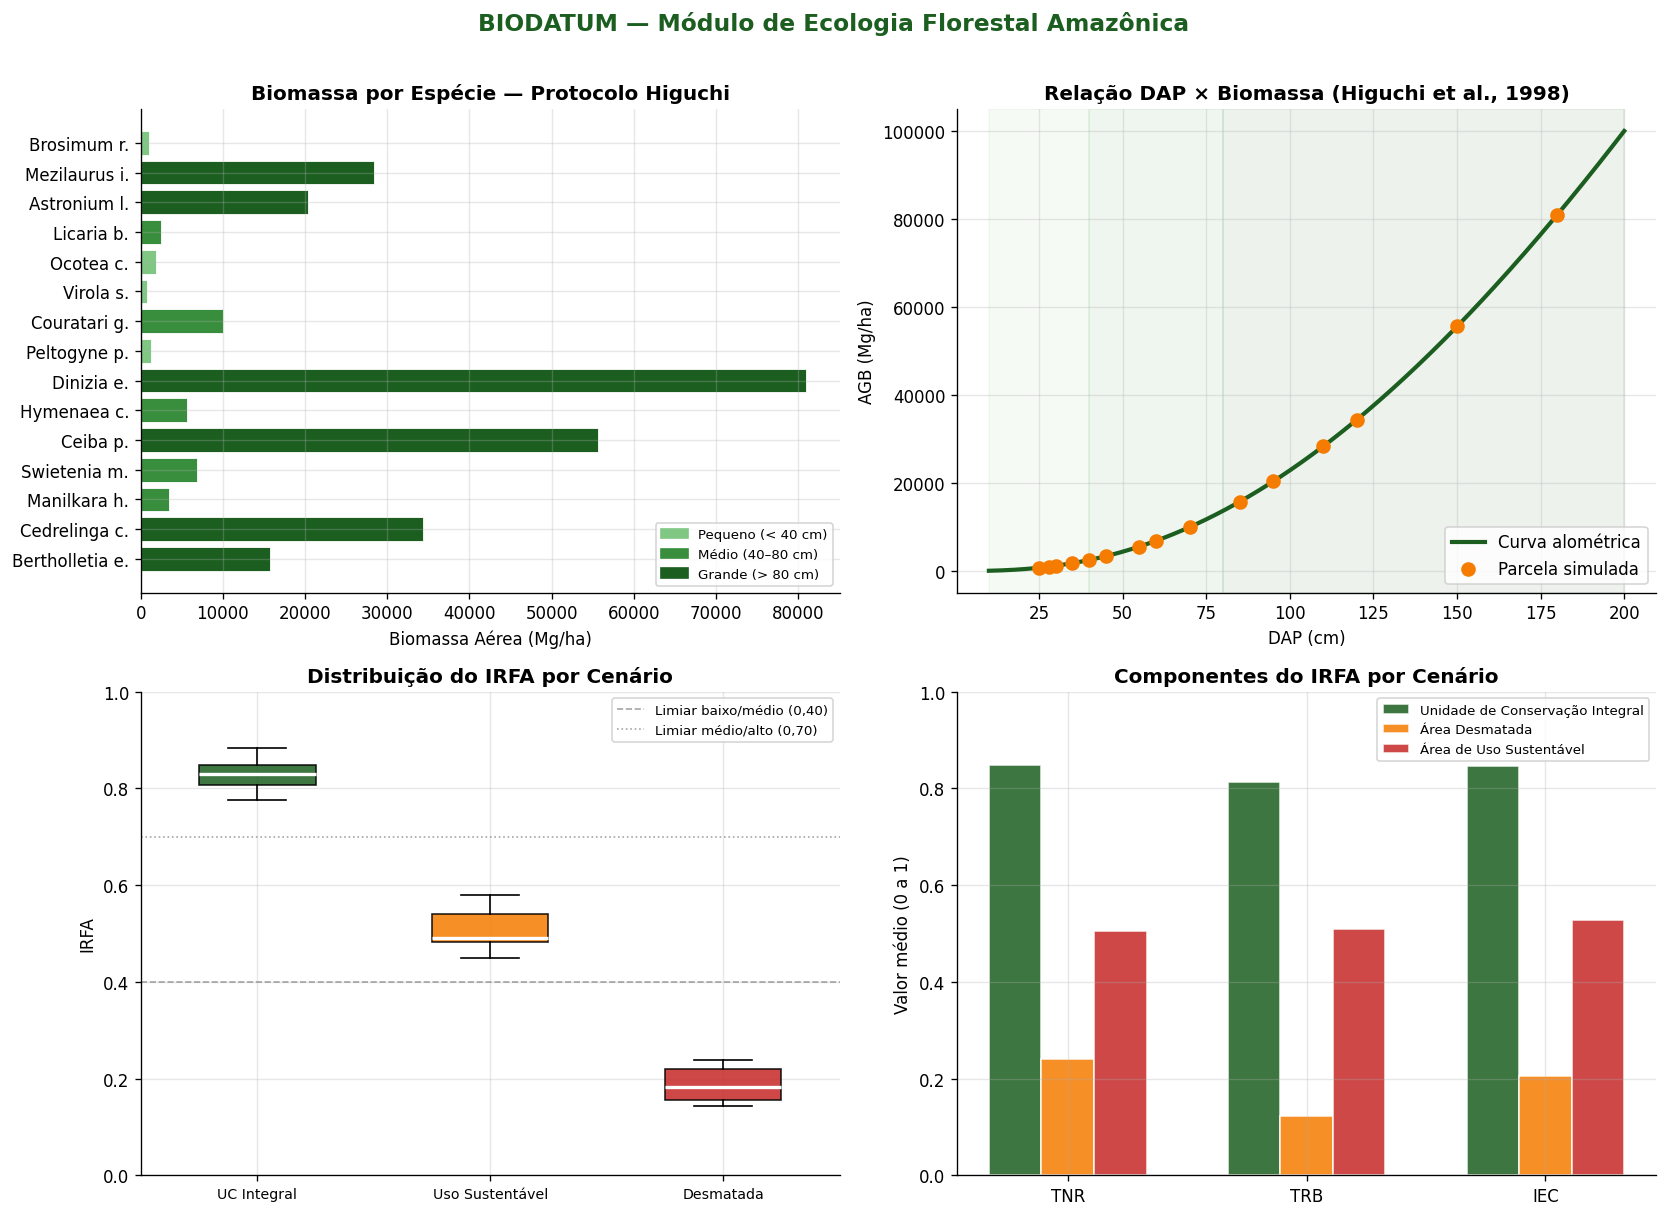

📊 Figura salva em: biodatum_resultados.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BIODATUM — Módulo de Ecologia Florestal Amazônica',
             fontsize=14, fontweight='bold', color=COR_VERDE_ESCURO, y=1.01)

# -----------------------------------------------------------
# GRÁFICO 1 — Distribuição de biomassa por espécie
# -----------------------------------------------------------
ax1 = axes[0, 0]
cores_porte = {
    'Pequeno (< 40 cm)': COR_VERDE_CLARO,
    'Médio (40–80 cm)': COR_VERDE_MEDIO,
    'Grande (> 80 cm)': COR_VERDE_ESCURO
}
cores_barras = df['Porte'].map(cores_porte)
barras = ax1.barh(
    df['Espécie'].str.split().str[0] + ' ' + df['Espécie'].str.split().str[1].str[0] + '.',
    df['AGB_Mg_ha'],
    color=cores_barras,
    edgecolor='white',
    linewidth=0.5
)
ax1.set_xlabel('Biomassa Aérea (Mg/ha)')
ax1.set_title('Biomassa por Espécie — Protocolo Higuchi', fontweight='bold')
legenda_porte = [mpatches.Patch(color=c, label=l) for l, c in cores_porte.items()]
ax1.legend(handles=legenda_porte, fontsize=8, loc='lower right')

# -----------------------------------------------------------
# GRÁFICO 2 — Curva alométrica DAP × AGB
# -----------------------------------------------------------
ax2 = axes[0, 1]
dap_curva = np.linspace(10, 200, 300)
agb_curva = estimar_biomassa(dap_curva)
ax2.plot(dap_curva, agb_curva, color=COR_VERDE_ESCURO, linewidth=2.5, label='Curva alométrica')
ax2.scatter(df['DAP_cm'], df['AGB_Mg_ha'], color=COR_LARANJA, zorder=5, s=60, label='Parcela simulada')
ax2.set_xlabel('DAP (cm)')
ax2.set_ylabel('AGB (Mg/ha)')
ax2.set_title('Relação DAP × Biomassa (Higuchi et al., 1998)', fontweight='bold')
ax2.legend()
# Sombrear faixas de porte
ax2.axvspan(10, 40, alpha=0.08, color=COR_VERDE_CLARO, label='Pequeno')
ax2.axvspan(40, 80, alpha=0.08, color=COR_VERDE_MEDIO)
ax2.axvspan(80, 200, alpha=0.08, color=COR_VERDE_ESCURO)

# -----------------------------------------------------------
# GRÁFICO 3 — Distribuição do IRFA por cenário (boxplot)
# -----------------------------------------------------------
ax3 = axes[1, 0]
nomes_cenarios = list(cenarios.keys())
dados_irfa_plot = [
    df_irfa[df_irfa['Cenário'] == n.replace('\n', ' ')]['IRFA'].values
    for n in nomes_cenarios
]
cores_cenarios = [c['cor'] for c in cenarios.values()]

bp = ax3.boxplot(dados_irfa_plot, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
for patch, cor in zip(bp['boxes'], cores_cenarios):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)

# Linhas de limiar
ax3.axhline(0.4, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Limiar baixo/médio (0,40)')
ax3.axhline(0.7, color='gray', linestyle=':',  linewidth=1, alpha=0.7, label='Limiar médio/alto (0,70)')
ax3.set_xticks([1, 2, 3])
ax3.set_xticklabels(['UC Integral', 'Uso Sustentável', 'Desmatada'], fontsize=8.5)
ax3.set_ylabel('IRFA')
ax3.set_ylim(0, 1)
ax3.set_title('Distribuição do IRFA por Cenário', fontweight='bold')
ax3.legend(fontsize=8)

# -----------------------------------------------------------
# GRÁFICO 4 — Radar / barras empilhadas dos componentes
# -----------------------------------------------------------
ax4 = axes[1, 1]
componentes = ['TNR', 'TRB', 'IEC']
medias = df_irfa.groupby('Cenário')[componentes].mean()

x = np.arange(len(componentes))
largura = 0.22

for i, (cenario, row) in enumerate(medias.iterrows()):
    nome_curto = cenario.split('(')[0].strip()
    cor = list(cenarios.values())[i]['cor']
    ax4.bar(x + i * largura, row.values, largura, label=nome_curto, color=cor, alpha=0.85, edgecolor='white')

ax4.set_xticks(x + largura)
ax4.set_xticklabels(componentes, fontsize=10)
ax4.set_ylabel('Valor médio (0 a 1)')
ax4.set_ylim(0, 1)
ax4.set_title('Componentes do IRFA por Cenário', fontweight='bold')
ax4.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('biodatum_resultados.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Figura salva em: biodatum_resultados.png')

---
## 5. Interpretação dos Resultados

In [5]:
print('=' * 70)
print('              INTERPRETAÇÃO DOS RESULTADOS')
print('=' * 70)

biomassa_total = df['AGB_Mg_ha'].sum()
biomassa_media = df['AGB_Mg_ha'].mean()
irfa_medio_uc  = df_irfa[df_irfa['Cenário'].str.contains('Integral')]['IRFA'].mean()
irfa_medio_uso = df_irfa[df_irfa['Cenário'].str.contains('Sustentável')]['IRFA'].mean()
irfa_medio_deg = df_irfa[df_irfa['Cenário'].str.contains('Desmatada')]['IRFA'].mean()

print(f"""
📌 MÓDULO 1 — BIOMASSA (PROTOCOLO HIGUCHI)

   A parcela simulada (15 árvores) apresentou biomassa total de
   {biomassa_total:.1f} Mg/ha, com média de {biomassa_media:.1f} Mg/ha por árvore.

   A curva alométrica evidencia a relação não-linear entre DAP e biomassa:
   árvores com DAP > 80 cm concentram a maior parte do estoque carbono
   da floresta, o que sublinha a importância das espécies emergentes
   (ex.: Dinizia excelsa, Ceiba pentandra) para o balanço de carbono.

   Este padrão é consistente com estudos de parcelas permanentes da
   Amazônia central (Higuchi et al., 1998; Chambers et al., 2001).

{'=' * 68}

📌 MÓDULO 2 — ÍNDICE IRFA

   Os três cenários simulados demonstraram a capacidade discriminativa
   do IRFA para diferentes estados de conservação:

   • Unidade de Conservação Integral : IRFA = {irfa_medio_uc:.3f}  → Alta resiliência ✅
   • Área de Uso Sustentável          : IRFA = {irfa_medio_uso:.3f}  → Média resiliência ⚠️
   • Área Desmatada                   : IRFA = {irfa_medio_deg:.3f}  → Baixa resiliência ❌

   A decomposição por componentes (TNR, TRB, IEC) revela que a
   degradação impacta de forma relativamente homogênea as três
   dimensões, sugerindo que perturbações severas comprometem
   simultaneamente a regeneração, a biomassa e a estrutura
   da comunidade arbórea.

{'=' * 68}

📌 PERSPECTIVAS PARA O BIODATUM COMPLETO

   Este protótipo constitui a base do módulo de Inteligência Florestal
   da plataforma BIODATUM. Nas etapas seguintes, o sistema integrará:

   → Dados de sensoriamento remoto (PRODES/INPE, LiDAR)
   → Séries climáticas históricas e projeções CMIP6
   → Modelos de inferência causal (DoWhy / CausalML)
   → Sonificação de dados ecológicos
   → Interface geoespacial interativa

   BIODATUM — Plataforma Prescritiva de Inteligência Climática
   e Bioeconômica de Fronteira para a Amazônia Brasileira
   PPGCASA / UFAM — 2026
""")

              INTERPRETAÇÃO DOS RESULTADOS

📌 MÓDULO 1 — BIOMASSA (PROTOCOLO HIGUCHI)

   A parcela simulada (15 árvores) apresentou biomassa total de
   268610.1 Mg/ha, com média de 17907.3 Mg/ha por árvore.

   A curva alométrica evidencia a relação não-linear entre DAP e biomassa:
   árvores com DAP > 80 cm concentram a maior parte do estoque carbono
   da floresta, o que sublinha a importância das espécies emergentes
   (ex.: Dinizia excelsa, Ceiba pentandra) para o balanço de carbono.

   Este padrão é consistente com estudos de parcelas permanentes da
   Amazônia central (Higuchi et al., 1998; Chambers et al., 2001).


📌 MÓDULO 2 — ÍNDICE IRFA

   Os três cenários simulados demonstraram a capacidade discriminativa
   do IRFA para diferentes estados de conservação:

   • Unidade de Conservação Integral : IRFA = 0.827  → Alta resiliência ✅
   • Área de Uso Sustentável          : IRFA = 0.509  → Média resiliência ⚠️
   • Área Desmatada                   : IRFA = 0.187  → Baixa resil

---

### Referências

- HIGUCHI, N. et al. **Biomassa da parte aérea da vegetação da floresta tropical úmida de terra-firme da Amazônia brasileira**. Acta Amazônica, v. 28, n. 2, p. 153–166, 1998.
- CHAMBERS, J. Q. et al. **Tree damage, allometric relationships, and above-ground net primary production in central Amazon forest**. Forest Ecology and Management, v. 152, p. 73–84, 2001.
- INPE/PRODES. **Monitoramento do desmatamento da floresta amazônica brasileira por satélite**. Instituto Nacional de Pesquisas Espaciais, 2024.

---
*Protótipo desenvolvido no contexto do Projeto de Tese de Doutorado — PPGCASA/UFAM, 2026.*